In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/eeg-psychiatric-disorders-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eeg-psychiatric-disorders-dataset' dataset.
Path to dataset files: /kaggle/input/eeg-psychiatric-disorders-dataset


In [ ]:
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/eeg-psychiatric-disorders-dataset


In [ ]:
base = pd.read_csv('/kaggle/input/eeg-psychiatric-disorders-dataset/EEG.machinelearing_data_BRMH.csv')

In [ ]:
base.head()

,no.,sex,age,eeg.date,education,IQ,main.disorder,specific.disorder,AB.A.delta.a.FP1,AB.A.delta.b.FP2,...,COH.F.gamma.o.Pz.p.P4,COH.F.gamma.o.Pz.q.T6,COH.F.gamma.o.Pz.r.O1,COH.F.gamma.o.Pz.s.O2,COH.F.gamma.p.P4.q.T6,COH.F.gamma.p.P4.r.O1,COH.F.gamma.p.P4.s.O2,COH.F.gamma.q.T6.r.O1,COH.F.gamma.q.T6.s.O2,COH.F.gamma.r.O1.s.O2
0,1,M,57.0,2012.8.30,NaN,NaN,Addictive disorder,Alcohol use disorder,35.998557,21.717375,...,55.989192,16.739679,23.452271,45.678820,30.167520,16.918761,48.850427,9.422630,34.507082,28.613029
1,2,M,37.0,2012.9.6,6.0,120.0,Addictive disorder,Alcohol use disorder,13.425118,11.002916,...,45.595619,17.510824,26.777368,28.201062,57.108861,32.375401,60.351749,13.900981,57.831848,43.463261
2,3,M,32.0,2012.9.10,16.0,113.0,Addictive disorder,Alcohol use disorder,29.941780,27.544684,...,99.475453,70.654171,39.131547,69.920996,71.063644,38.534505,69.908764,27.180532,64.803155,31.485799
3,4,M,35.0,2012.10.8,18.0,126.0,Addictive disorder,Alcohol use disorder,21.496226,21.846832,...,59.986561,63.822201,36.478254,47.117006,84.658376,24.724096,50.299349,35.319695,79.822944,41.141873
4,5,M,36.0,2012.10.18,16.0,112.0,Addictive disorder,Alcohol use disorder,37.775667,33.607679,...,61.462720,59.166097,51.465531,58.635415,80.685608,62.138436,75.888749,61.003944,87.455509,70.531662


In [ ]:
base.shape

(945, 1149)

In [ ]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Columns: 1149 entries, no. to COH.F.gamma.r.O1.s.O2
dtypes: float64(1144), int64(1), object(4)
memory usage: 8.3+ MB


In [ ]:
missing = base.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
Unnamed: 122,945
education,15
IQ,13


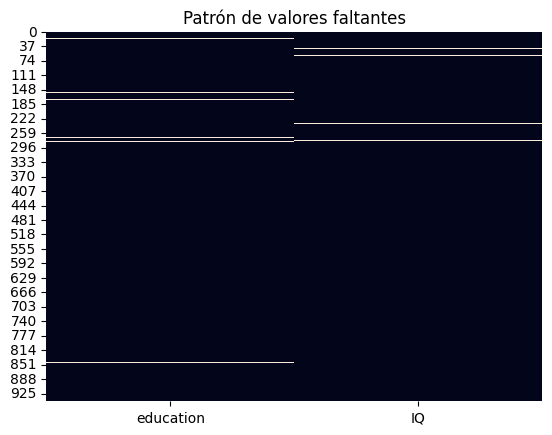

In [ ]:
sns.heatmap(base[['education', 'IQ']].isnull(), cbar=False)
plt.title("Patrón de valores faltantes")
plt.show()

In [ ]:
base.describe()

,no.,age,education,IQ,AB.A.delta.a.FP1,AB.A.delta.b.FP2,AB.A.delta.c.F7,AB.A.delta.d.F3,AB.A.delta.e.Fz,AB.A.delta.f.F4,...,COH.F.gamma.o.Pz.p.P4,COH.F.gamma.o.Pz.q.T6,COH.F.gamma.o.Pz.r.O1,COH.F.gamma.o.Pz.s.O2,COH.F.gamma.p.P4.q.T6,COH.F.gamma.p.P4.r.O1,COH.F.gamma.p.P4.s.O2,COH.F.gamma.q.T6.r.O1,COH.F.gamma.q.T6.s.O2,COH.F.gamma.r.O1.s.O2
count,945.000000,945.000000,930.000000,932.000000,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000,...,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000
mean,473.000000,30.594804,13.438710,101.580472,20.182936,21.177584,17.749553,18.901698,20.447079,19.490329,...,75.889633,55.049113,56.959796,60.739169,69.829254,47.862489,66.832798,39.301406,66.153213,57.056207
std,272.942302,11.781592,2.550461,17.022414,11.282022,12.230662,10.003598,9.079482,9.742912,9.252500,...,15.861641,19.541956,18.326785,18.052887,17.725321,19.685722,17.028701,20.790933,18.088548,19.600107
min,1.000000,18.000000,0.000000,49.000000,3.272260,3.244199,3.050507,3.412618,5.066593,4.048931,...,12.611954,0.519048,6.926792,0.708008,2.421748,0.036664,1.032207,1.228502,0.363268,3.988805
25%,237.000000,21.730000,12.000000,91.000000,12.784872,13.019269,11.134327,12.460586,13.548645,12.637717,...,68.014443,41.607506,43.682444,48.374883,58.937785,32.581046,55.872070,22.049743,54.710605,43.955229
50%,473.000000,26.150000,13.000000,102.000000,17.065286,17.838251,15.541469,16.733004,18.065276,17.432568,...,78.647712,55.158858,56.657348,61.257972,72.298636,45.719426,68.238375,36.549938,67.988937,57.515871
75%,709.000000,35.450000,16.000000,114.000000,24.492760,25.654394,21.623961,23.347900,25.573096,23.956748,...,87.398387,69.740640,70.649245,73.979100,83.066877,62.081839,79.192418,54.169209,79.527764,71.626382
max,945.000000,71.880000,20.000000,145.000000,92.826192,101.515687,91.373456,82.544167,101.566662,77.197502,...,99.678649,100.000000,99.307895,100.000000,99.581629,98.720067,99.650154,98.413320,100.000000,99.287092


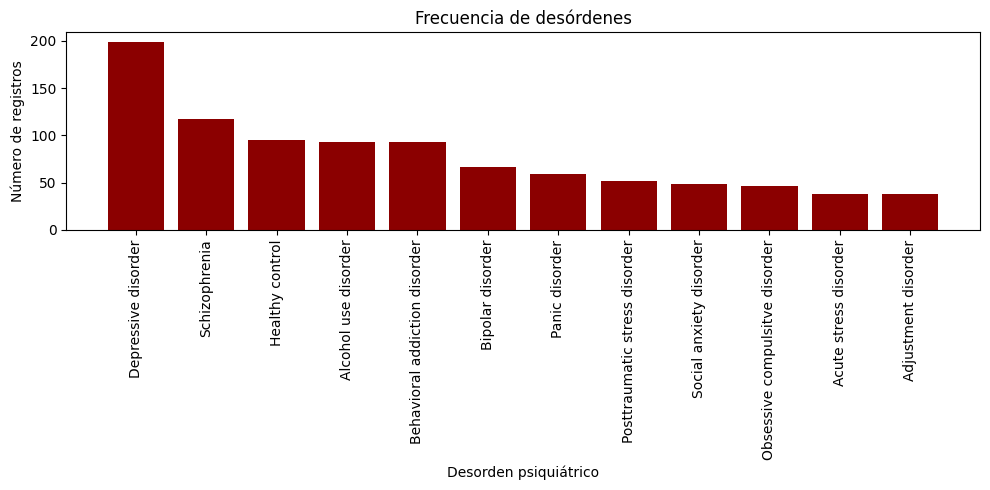

In [ ]:
disorder_counts = base["specific.disorder"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(disorder_counts.index, disorder_counts.values, color ='darkred')
plt.xlabel("Desorden psiquiátrico")
plt.ylabel("Número de registros")
plt.title("Frecuencia de desórdenes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

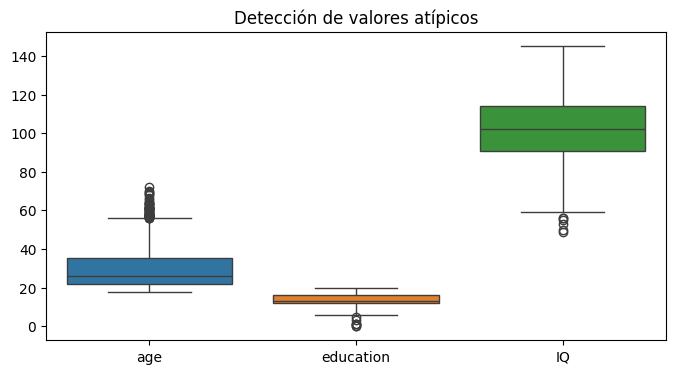

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=base[['age', 'education', 'IQ']])
plt.title("Detección de valores atípicos")
plt.show()

In [ ]:
categorical_cols = ['sex', 'main.disorder', 'specific.disorder']
for col in categorical_cols:
    print(col)
    print(base[col].value_counts())
    print("-----")

sex
sex
M    601
F    344
Name: count, dtype: int64
-----
main.disorder
main.disorder
Mood disorder                         266
Addictive disorder                    186
Trauma and stress related disorder    128
Schizophrenia                         117
Anxiety disorder                      107
Healthy control                        95
Obsessive compulsive disorder          46
Name: count, dtype: int64
-----
specific.disorder
specific.disorder
Depressive disorder               199
Schizophrenia                     117
Healthy control                    95
Alcohol use disorder               93
Behavioral addiction disorder      93
Bipolar disorder                   67
Panic disorder                     59
Posttraumatic stress disorder      52
Social anxiety disorder            48
Obsessive compulsitve disorder     46
Acute stress disorder              38
Adjustment disorder                38
Name: count, dtype: int64
-----


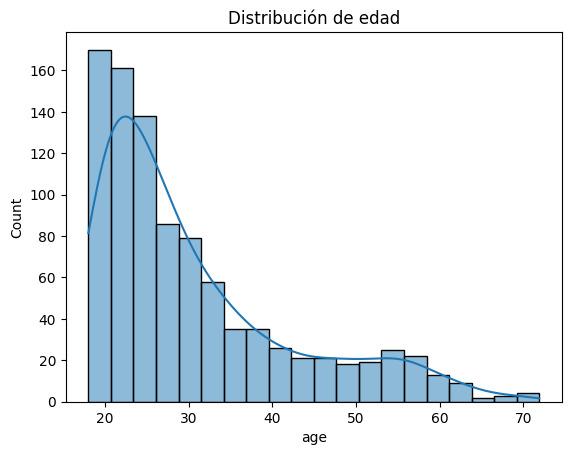

In [ ]:
sns.histplot(base['age'], kde=True)
plt.title("Distribución de edad")
plt.show()

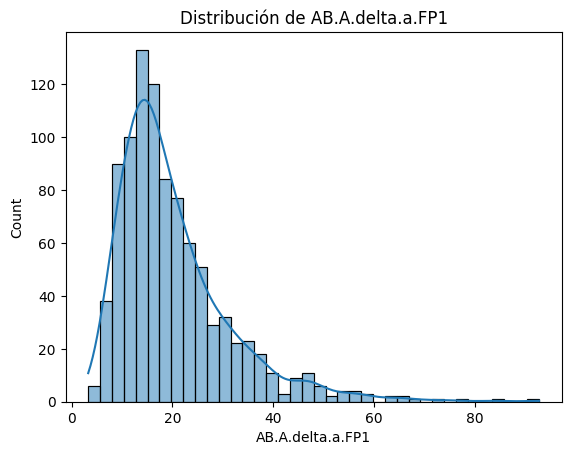

In [ ]:
sample_ab = [c for c in base.columns if c.startswith("AB")][0]

sns.histplot(base[sample_ab], kde=True)
plt.title(f"Distribución de {sample_ab}")
plt.show()

In [ ]:
base['eeg.date'] = pd.to_datetime(base['eeg.date'], errors='coerce')

In [ ]:
base['year'] = base['eeg.date'].dt.year
base['year'].value_counts().sort_index()

,count
year,
2011.0,113
2012.0,54
2013.0,88
2014.0,105
2015.0,75
2016.0,155
2017.0,158
2018.0,186
2019.0,7


In [ ]:
base['AUD'] = (base['specific.disorder'] == 'Alcohol use disorder').astype(int)

In [ ]:
base['AUD'].value_counts()

,count
AUD,
0,852
1,93


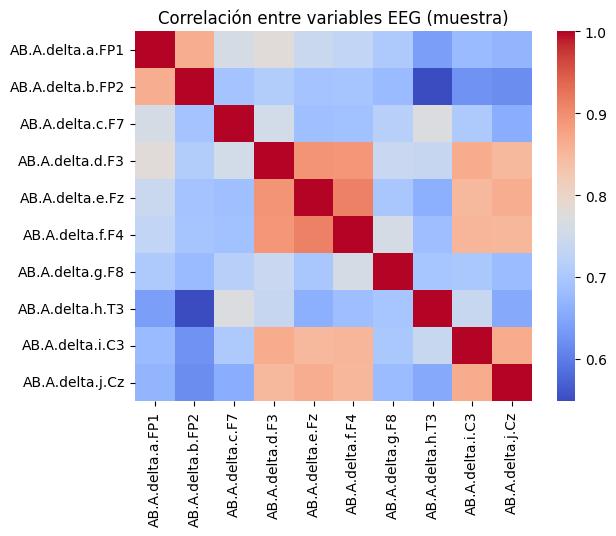

In [ ]:
eeg_sample = base[[c for c in base.columns if c.startswith("AB")][:10]]
corr = eeg_sample.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlación entre variables EEG (muestra)")
plt.show()